In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import pandas as pd
import numpy as np

In [2]:
s_level_area=gpd.read_file('s_level_area.geojson')
gdf_area=gpd.read_file('gdf_area.geojson')
gdf_blank_area=gpd.read_file('gdf_blank_area.geojson')
new_candidates_gdf=gpd.read_file('new_candidates_gdf.geojson')

In [3]:
geometry_target=gpd.read_parquet('geometry_target.parquet')
geometry_competitor=gpd.read_parquet('geometry_competitor.parquet')

In [4]:
poi_geo_data=gpd.read_parquet('poi_geo_data.parquet')

In [5]:
gdf_coffee=gpd.read_file('gdf_coffee.geojson')
gdf_subway=gpd.read_file('gdf_subway.geojson')
gdf_offices=gpd.read_file('gdf_offices.geojson')
gdf_malls=gpd.read_file('gdf_malls.geojson')

In [6]:
#poi_geo_data.rename(columns={'typ_co_bro':'subclass'},inplace=True)
#replace_map = {'05': '咖啡', '06': '购物中心', '12': '办公楼', '15': '地铁出入口'}
#poi_geo_data['subclass'] = poi_geo_data['subclass'].replace(replace_map)

In [7]:
#poi_geo_data.to_parquet('poi_geo_data.parquet')

In [8]:
#new_candidates_gdf=new_candidates_gdf.reset_index().rename(columns={'index':'id'})

In [9]:
#new_candidates_gdf.to_file('new_candidates_gdf.geojson')

In [10]:
#gdf_coffee.to_file('gdf_coffee.geojson')
#gdf_subway.to_file('gdf_subway.geojson')
#gdf_offices.to_file('gdf_offices.geojson')
#gdf_malls.to_file('gdf_malls.geojson')

In [11]:
#gdf_coffee=poi_geo_data[poi_geo_data['subclass']=='咖啡'].copy()
#gdf_subway=poi_geo_data[poi_geo_data['subclass']=='地铁出入口'].copy()
#gdf_offices=poi_geo_data[poi_geo_data['subclass']=='办公楼'].copy()
#gdf_malls=poi_geo_data[poi_geo_data['subclass']=='购物中心'].copy()

# 1.Top 点位标注地图

## 1.1裁剪top点位周边所有要素

In [12]:
s_level_points=gpd.sjoin(new_candidates_gdf,s_level_area,how='inner',predicate='within')

In [13]:
top_point = s_level_points[s_level_points['id'] == 400].copy().reset_index(drop=True)

In [14]:
top_buffer = top_point.geometry.buffer(1000)

In [15]:
clip_gdf = gpd.GeoDataFrame(geometry=top_buffer, crs="EPSG:32650")

In [16]:
starbucks_clip = gpd.clip(geometry_target, clip_gdf)
competitor_clip = gpd.clip(geometry_competitor, clip_gdf)
coffee_clip = gpd.clip(gdf_coffee.to_crs("EPSG:32650"), clip_gdf)
subway_clip = gpd.clip(gdf_subway.to_crs("EPSG:32650"), clip_gdf)
offices_clip = gpd.clip(gdf_offices.to_crs("EPSG:32650"), clip_gdf)
malls_clip = gpd.clip(gdf_malls.to_crs("EPSG:32650"), clip_gdf)

In [17]:
plt.rcParams["font.family"] = ["SimHei", "WenQuanYi Micro Hei", "Heiti TC"]
plt.rcParams["axes.unicode_minus"] = False
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 300
plt.rcParams["figure.figsize"] = (10, 10) 

In [18]:
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans'] 
plt.rcParams['axes.unicode_minus'] = False  

In [ ]:
import matplotlib.patches as mpatches

findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: 

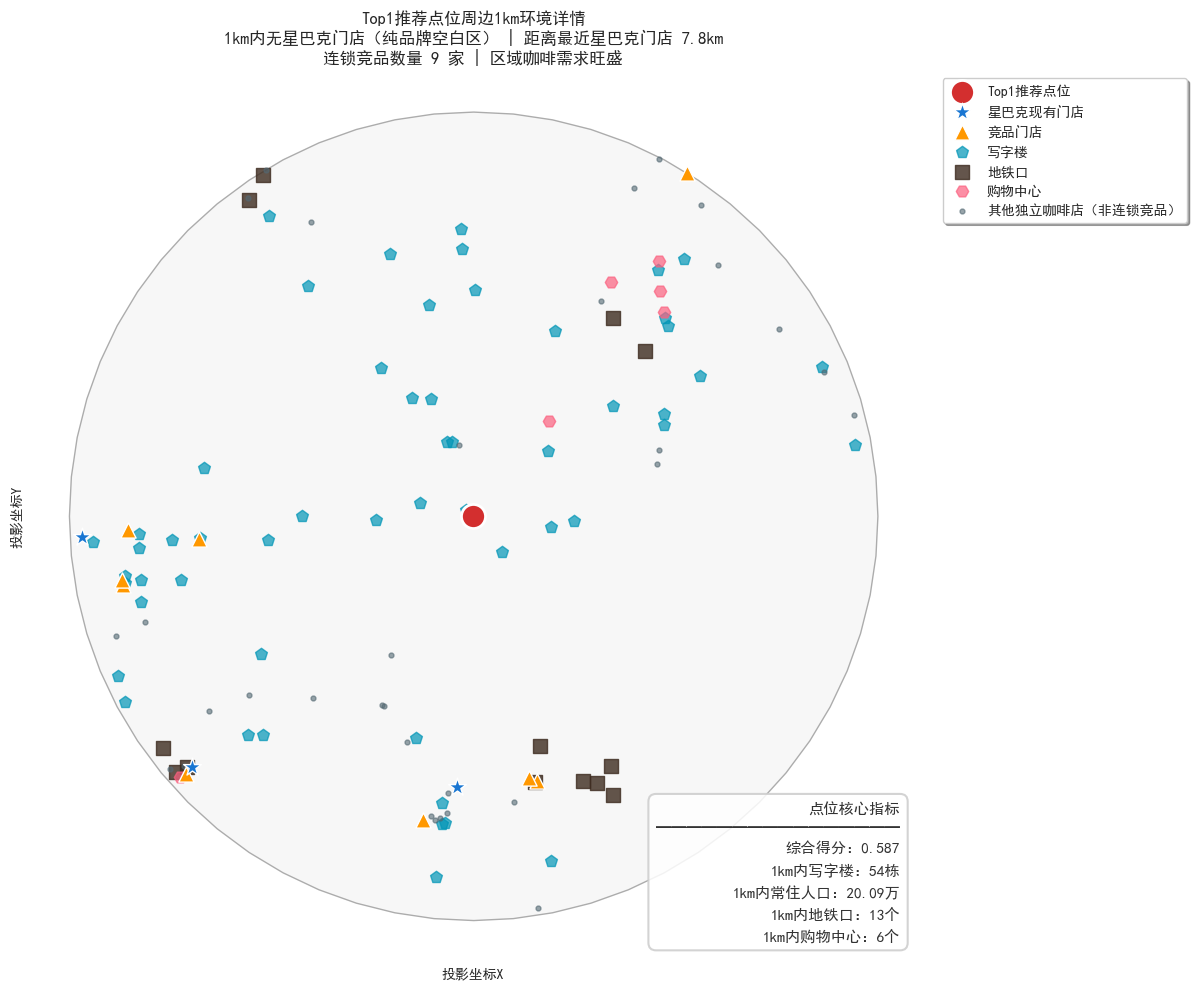

In [46]:
fig, ax = plt.subplots(figsize=(12, 10), dpi=100)


clip_gdf.plot(ax=ax, color="#f5f5f5", edgecolor="#999999", linewidth=1, alpha=0.8)


top_point.plot(ax=ax, marker="o", color="#D32F2F", markersize=300, 
               label="Top1推荐点位", zorder=10, edgecolors='white', linewidth=2)
starbucks_clip.plot(ax=ax, marker="*", color="#1976D2", markersize=180, 
                    label="星巴克现有门店", zorder=9, edgecolors='white', linewidth=1)
competitor_clip.plot(ax=ax, marker="^", color="#FF9800", markersize=120, 
                     label="竞品门店", zorder=8, edgecolors='white', linewidth=1)
offices_clip.plot(ax=ax, marker="p", color="#0095b6", markersize=80, 
                  label="写字楼", zorder=7, alpha=0.7)
subway_clip.plot(ax=ax, marker="s", color="#3d2b1f", markersize=100, 
                 label="地铁口", zorder=7, alpha=0.8)
malls_clip.plot(ax=ax, marker="H", color="#fb607f", markersize=80, 
                label="购物中心", zorder=7, alpha=0.7)
coffee_clip.plot(ax=ax, marker=".", color="#536872", markersize=50, 
                 label="其他独立咖啡店（非连锁竞品）", zorder=7, alpha=0.6)

distance_to_nearest_starbucks = top_point.geometry.distance(geometry_target.to_crs("EPSG:32650").geometry).min() / 1000

ax.set_title(
    f"Top1推荐点位周边1km环境详情\n"
    f"1km内无星巴克门店（纯品牌空白区） | 距离最近星巴克门店 {distance_to_nearest_starbucks:.1f}km\n"
    f"连锁竞品数量 9 家 | 区域咖啡需求旺盛",
    fontweight="bold", fontsize=12
)


ax.set_xlabel("投影坐标X", fontsize=10)
ax.set_ylabel("投影坐标Y", fontsize=10)


ax.legend(loc="upper left", fontsize=10, frameon=True, 
          fancybox=True, shadow=True, bbox_to_anchor=(1.02, 1))

ax.set_xticks([])
ax.set_yticks([])

sns.despine(left=True, bottom=True)

plt.tight_layout()

info_text = (
    "点位核心指标\n"
    "━━━━━━━━━━━━━━━━\n"
    "综合得分：0.587\n"
    "1km内写字楼：54栋\n"
    "1km内常住人口：20.09万\n"
    "1km内地铁口：13个\n"
    "1km内购物中心：6个"
)
ax.text(
    0.98, 0.02,                   
    info_text,
    transform=ax.transAxes,          
    fontsize=11,
    verticalalignment='bottom',     
    horizontalalignment='right',    
    fontweight='bold',
    color='#333333',                 
    bbox=dict(
        boxstyle='round,pad=0.5',   
        facecolor='white',           
        edgecolor='#cccccc',         
        alpha=0.85,                 
        linewidth=1.5,
    ),
    linespacing=1.6,                 
    family='sans-serif',
)


plt.savefig("Top1推荐点位周边详情图.png", dpi=300, bbox_inches="tight", 
            facecolor='white', edgecolor='none')
plt.show()

## 1.2核心业务洞察

在1km 咖啡门店的核心经营辐射范围内，从三个核心维度评估这个点位的价值：

品牌机会：点位 1km 内没有星巴克的现有门店，距离最近的星巴克有 7.8 公里，是纯品牌辐射空白区，没有同品牌客流分流的问题，能帮星巴克快速填补区域覆盖缺口；

客流确定性：点位周边 1km 内有 54 栋写字楼、20.9 万常住人口、13 个地铁口和 6 个购物中心，办公、居住、通勤、商业全场景覆盖，能保障门店全时段、全周的稳定营收；

市场风险验证：周边有 9 家瑞幸、库迪这类核心连锁竞品，还有大量独立咖啡店，已经充分验证了这个区域的咖啡消费需求非常旺盛，不用从零培育市场，极大降低了开店的试错成本。

综合来看，这个点位完美匹配“找有成熟需求的品牌空白市场”的选址策略，是第一优先级的开店点位。